In [2]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from afolu.defs.assets.constants import LABEL_LIST
from afolu.defs.assets.emissions import generate_model_objects

c:\Users\lain\Documents\AFOLU\.venv\Lib\site-packages\munch\__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [4]:
ZONE = "MEX+Guadalajara"

In [5]:
df_area = (
    pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
    .set_index("label")
    .transpose()
    .reset_index(names="time_period")
    .assign(time_period=lambda df: df["time_period"].astype(int).add(2000))
)
df_area.index = pd.RangeIndex(
    start=df_area["time_period"].min(),
    stop=df_area["time_period"].max() + 1,
    name="index",
)
df_area = df_area.drop(columns=["time_period"])
df_area.index.name = "year"

df_area_frac = df_area.div(df_area.sum(axis=1), axis=0)

In [6]:
transitions = pd.read_csv(
    out_path / "small" / "transition" / "cube" / f"{ZONE}.csv",
).set_index("time_period")

In [7]:
arr = xr.DataArray(
    transitions.to_numpy().reshape((len(transitions), 11, 11)),
    dims=["time_period", "start", "end"],
    coords={
        "time_period": transitions.index,
        "start": list(LABEL_LIST),
        "end": list(LABEL_LIST),
    },
)

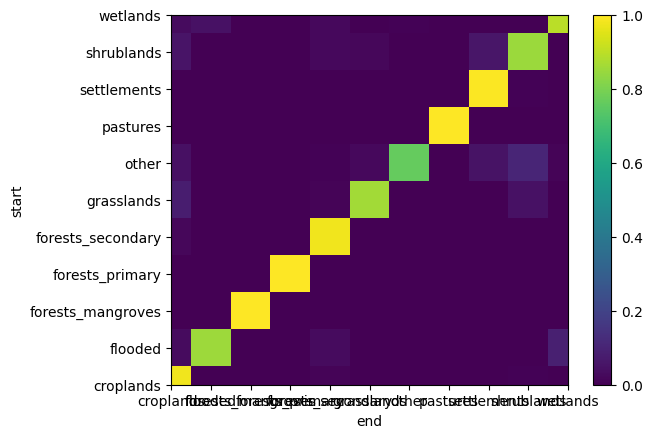

In [8]:
mean_transition_mat = arr.sel(time_period=slice(17, 21)).mean(dim="time_period")
mean_transition_mat.plot()

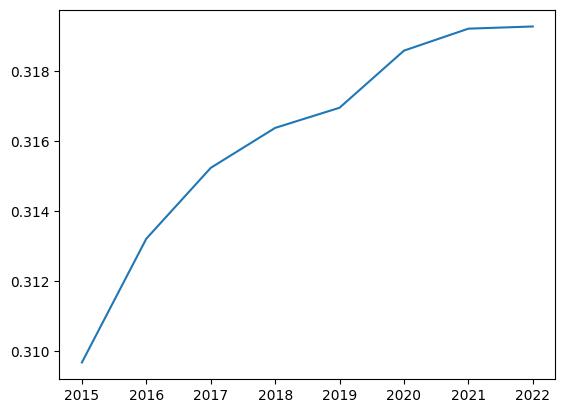

In [9]:
x = range(2015, 2023)
y = df_area_frac["settlements"].loc[2015:].to_numpy()

plt.plot(x, y)

In [10]:
def predict(
    last_year: float,
    last_val: float,
    *,
    nyears: int,
    slope: float,
    scale_factor: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    slope = slope * scale_factor

    x = np.arange(last_year, last_year + nyears)
    b = last_val - slope * last_year
    return x, x * slope + b

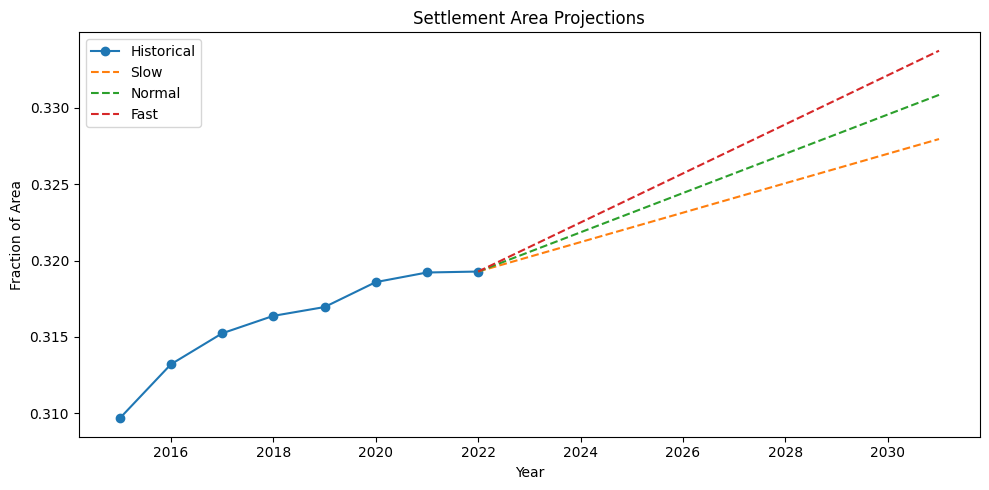

In [11]:
slope, _ = np.polyfit(x, y, deg=1)

last_year = x[-1]
last_val = y[-1]

x_future, y_future_slow = predict(
    last_year,
    last_val,
    nyears=10,
    slope=slope,
    scale_factor=0.75,
)
_, y_future_normal = predict(
    last_year,
    last_val,
    nyears=10,
    slope=slope,
    scale_factor=1.0,
)
_, y_future_fast = predict(
    last_year,
    last_val,
    nyears=10,
    slope=slope,
    scale_factor=1.25,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, label="Historical", marker="o")
ax.plot(x_future, y_future_slow, label="Slow", ls="--")
ax.plot(x_future, y_future_normal, label="Normal", ls="--")
ax.plot(x_future, y_future_fast, label="Fast", ls="--")

ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Area")
ax.set_title("Settlement Area Projections")
ax.legend()
fig.tight_layout()

In [12]:
def adjust_and_predict(
    Q: np.ndarray,
    x0: np.ndarray,
    targets: dict[int, float],
) -> tuple[np.ndarray, np.ndarray]:
    costs = {key: 0 for key in range(len(LABEL_LIST)) if key not in targets}

    vec_infimum = np.array([-999.0])
    vec_supremum = np.array([999.0])

    _, _, model_afolu, *_ = generate_model_objects()
    _, _, xT, *_ = model_afolu.qadj_get_inputs(
        Q,
        x0,
        targets,
        vec_infimum,
        vec_supremum,
    )

    Q_adj = model_afolu.q_adjuster.solve(
        Q,
        x0,
        xT,
        vec_infimum,
        vec_supremum,
        model_afolu.flag_ignore_constraint,
        costs_x=costs,
    )
    x_future = x0 @ Q_adj
    return Q_adj, x_future

In [13]:
def predict_all(
    Q: np.ndarray,
    x: np.ndarray,
    *,
    start_year: int,
    end_year: int,
    slope: float,
    scale_factor: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    settlements_idx = LABEL_LIST.index("settlements")

    Q_hist, y_hist = [], []

    for year in range(start_year, end_year + 1):
        _, y_next = predict(
            year,
            x[settlements_idx],
            nyears=2,
            slope=slope,
            scale_factor=scale_factor,
        )
        targets = {settlements_idx: y_next[-1]}
        with warnings.catch_warnings(action="ignore"):
            Q, x = adjust_and_predict(Q, x, targets)
        Q_hist.append(Q)
        y_hist.append(x)

    return np.array(Q_hist), np.array(y_hist)

In [14]:
all_preds = {}
for scale_factor, name in zip(
    [0.75, 1.0, 1.25], ["slow", "normal", "fast"], strict=False
):
    _, ypred = predict_all(
        mean_transition_mat.to_numpy(),
        df_area_frac.loc[2022].to_numpy(),
        start_year=2022,
        end_year=2050,
        slope=slope,
        scale_factor=scale_factor,
    )
    all_preds[name] = ypred

In [15]:
all_preds_df = {
    name: pd.DataFrame(
        np.array(ypred),
        columns=LABEL_LIST,
        index=range(2023, 2023 + len(ypred)),
    )
    for name, ypred in all_preds.items()
}

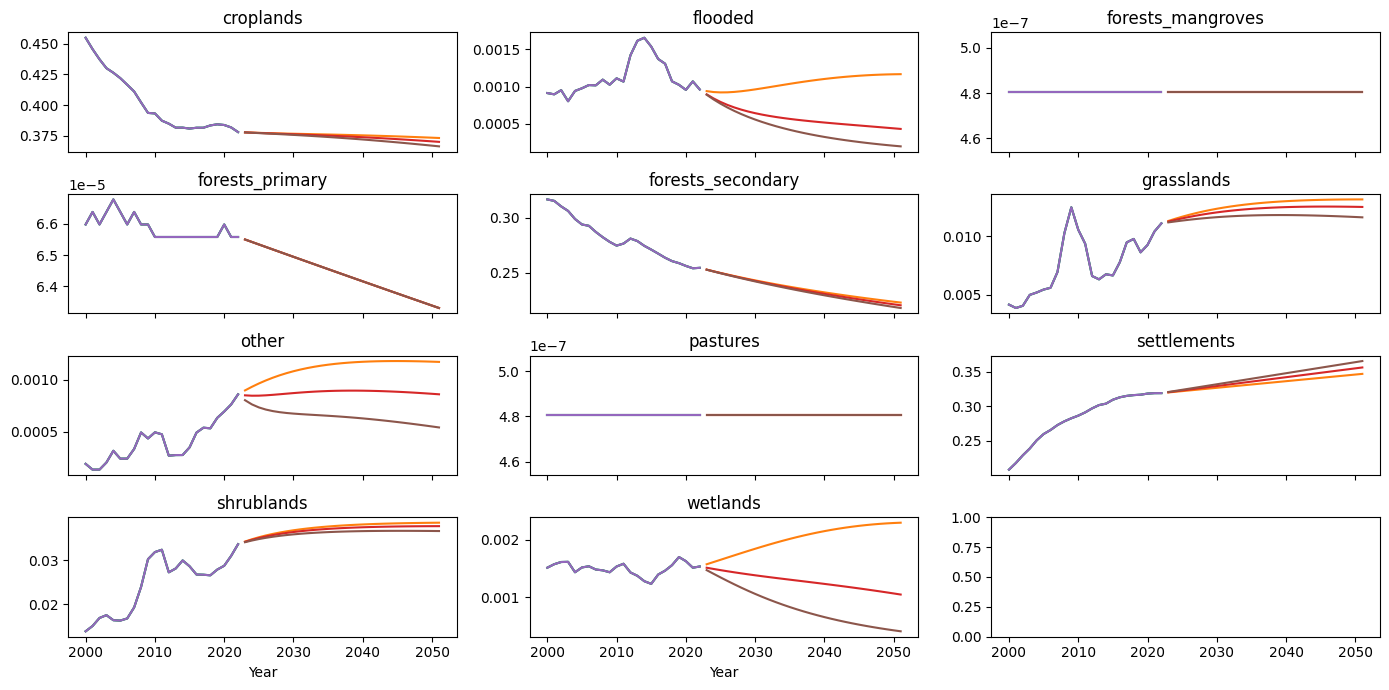

In [23]:
fig, axes = plt.subplots(4, 3, figsize=(14, 7), sharex=True)

for name, pred in all_preds_df.items():
    for i, label in enumerate(LABEL_LIST):
        ax = axes[i // 3, i % 3]
        df_area_frac[label].plot(ax=ax)
        ax.plot(pred.index, pred[label])
        ax.set_title(label)
        ax.set_xlabel("Year")
fig.tight_layout()